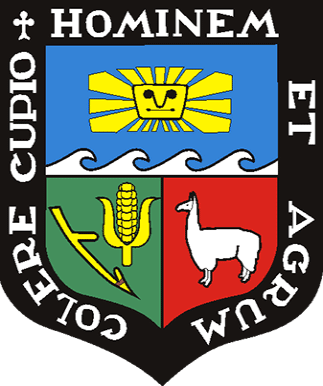
# **Universidad Nacional Agraria La Molina**
## **Facultad de Economía y Planificación**
## **Departamento Académico de Estadística e Informática**
## --------------------- **Examen Final** ---------------------
#### **Curso**: Lenguaje de Programación II
#### **Docente**: Ana Cecilia Vargas Paredes
#### **Integrantes:**
- Arroyo Arruz, Alejandra Margoth | 20211805
- Maguiña Tabory, Leonardo Fabio | 20241388
- Polo D'Arrigo, Salvatore Diego | 20241394
- Solis Leon, Nilo Andy | 20240734

# **Introducción y problemática**

Hoy en día, buscar trabajo en internet es algo completamente normal. Plataformas como **Trabajos Diarios** y **Bumeran** reciben miles de visitas al día de personas que están buscando empleo en el Perú. Sin embargo, no todas las ofertas que aparecen en estos portales son reales. Cada vez es más común encontrar publicaciones falsas que buscan engañar a quienes necesitan trabajo, aprovechándose de su situación.

Estas ofertas falsas suelen tener cosas en común: prometen sueldos muy altos, dicen que no se necesita experiencia, que el trabajo es fácil, no mencionan el nombre de la empresa o piden que el postulante haga algún pago antes de ser contratado. Caer en este tipo de engaños puede generar pérdidas de dinero y tiempo para las personas que buscan empleo.

Este trabajo busca detectar ese tipo de ofertas de forma automática, usando Python para revisar publicaciones de **Trabajos Diarios** y **Bumeran**. La idea es analizar el contenido de las ofertas y determinar cuáles tienen señales de ser sospechosas y cuáles parecen ser legítimas.


### **Fuentes seleccionadas**

Se eligieron Trabajos Diarios y Bumeran porque son portales de empleo con una gran cantidad de publicaciones diarias en el Perú. Ambas páginas nos dan bastante información para trabajar y, al tener tantas ofertas, es más probable que también contengan publicaciones falsas mezcladas entre las reales, que es justamente lo que queremos detectar.

**Trabajos Diarios:** Es un portal de empleo que reúne ofertas laborales de distintas fuentes y las publica de forma diaria. Tiene una variedad amplia de puestos, desde trabajos sin experiencia hasta posiciones más especializadas, lo que nos permite analizar distintos tipos de ofertas. La página **cuenta con un archivo robots.txt** que indica las siguientes normas:
- Content-Signal: search=yes, ai-train=no:  
  - search=yes: Permite indexar el contenido para motores de búsqueda.
  - ai-train=no: No se permite el uso del contenido con fin de entrenamiento de modelos de IA.
- Bots bloqueados:  
  - Amazonbot
  - Applebot-Extended
  - Bytespider
  - CCBot
  - ClaudeBot
  - CloudflareBrowserRenderingCrawler
  - Google-Extended
  - GPTBot
  - meta-externalagent
  - GPTBot
- Tiempo de espera entre solicitudes: 4 segundos

Página web: [pe.trabajosdiarios.com](https://pe.trabajosdiarios.com/)

**Bumeran:** Es un portal muy usado en el Perú y en otros países como Argentina. Presenta la información de cada oferta de manera clara y ordenada, lo que facilita obtener datos como el sueldo, el nombre de la empresa y los requisitos. Usar las dos páginas nos permite comparar resultados y tener una visión más completa del problema. La página **cuenta con un archivo robots.txt** el cual permite rastrear y scrapear las ofertas de los empleos que se publican cada día.

Según la página, para todo bot diferente de LinkedInBot se bloquea el scraping de páginas con URLs que coincidan con:
- /*recientes=true
- /*relevantes=true
- /empleos.html/111
- /empleos.html/100
- /empleos-area-*/111
- /empleos-area-*/100
- /en-*/empleos.html/111
- /en-*/empleos.html/100
- /empleos-busquedaext-
- /empleos/aptitus/*

Por ende, solo se accederán a ofertas laborales provenientes de URLs que coinciden con /empleos.html

Página web: [www.bumeran.com.pe](https://www.bumeran.com.pe/)



### **Objetivos del trabajo y posible solución**

El objetivo principal de este trabajo es identificar, de forma automática, qué ofertas laborales publicadas en Trabajos Diarios y Bumeran tienen características sospechosas. Para lograrlo, nos planteamos lo siguiente:

- Recopilar al menos 20 ofertas de cada portal usando un programa en Python.
- Buscar señales de alerta en cada oferta: sueldos exagerados, empresa sin nombre, falta de experiencia requerida o menciones a pagos previos.
- Clasificar cada oferta como **"Sospechosa"**, **Potencialmente sospechosa** o **"No Sospechosa"**.
- Guardar todos los resultados en un archivo CSV para poder revisarlos y compararlos fácilmente.

Así podremos detectar si de verdad la solicitud de trabajo es real o no.


### **Variables a extraer**

El análisis no revisa cada campo de la oferta por separado. Lo que se hace es tomar el texto completo de la descripción de cada publicación y buscar dentro de él una lista de palabras que suelen aparecer en ofertas sospechosas. Estas son las variables que se trabajan:

- **Texto de la descripción:** El contenido completo de la oferta laboral. Es el dato principal que se analiza en cada publicación.
- **Palabras clave sospechosas:** Hacer una lista de términos que se buscan dentro del texto, como "sin experiencia", "pago diario", "urgente", "multinivel", "ganancias ilimitadas", entre muchas otras para identificar los problemas más variados.
- **Frecuencia de aparición:** Cuántas veces aparece cada palabra clave dentro de la descripción de la oferta.
- **Puntaje total:** La suma de todas las frecuencias. Mientras más palabras sospechosas aparezcan, más alto es el puntaje.
- **Clasificación final:** El resultado del análisis según el puntaje obtenido:
  - 0 a 5 puntos = **No sospechosa**
  - 6 a 10 puntos = **Potencialmente sospechosa**
  - 11 puntos a más = **Sospechosa**
- **URL de la oferta:** El enlace de donde se extrajo la publicación, para poder verificarla si es necesario.

### **Código del scraping**

#### **Bumeran**

In [ ]:
import json
from bs4 import BeautifulSoup

import pandas as pd

import requests


texto = []
textoagregar = ""
url = ["https://www.bumeran.com.pe/empleos/coordinador-de-cumplimiento-tributario-jackeline-pimentel-1118332008.html",
"https://www.bumeran.com.pe/empleos/ejecutivo-de-afiliaciones-en-salud-piura-1118331627.html",
"https://www.bumeran.com.pe/empleos/ingeniero-de-mantenimiento-mecanico-1118331274.html",
"https://www.bumeran.com.pe/empleos/part-time-fulltime-sin-experiencia-solo-de-l-a-v-turno-manana-kontacta-solutions-s.a.c.-1118329494.html",
"https://www.bumeran.com.pe/empleos/especialista-de-almacenes-zoomlion-1118328915.html",
"https://www.bumeran.com.pe/empleos/call-center-part-time-surquillo-sol-resplandeciente-s.a.c.-1118333666.html",
"https://www.bumeran.com.pe/empleos/asesor-financiero-full-time-banco-ripley-jockey-plaza-banco-ripley-peru-s.a.-1118335917.html",
"https://www.bumeran.com.pe/empleos/inspector-de-seguridad-mina-subterranea-contrata-minera-cristobal-s.a.c.-1118334022.html",
"https://www.bumeran.com.pe/empleos/asistente-de-seleccion-huacho-redondos-s.a.-1118341483.html",
"https://www.bumeran.com.pe/empleos/jefe-de-operaciones-logisticas-1118341277.html",
"https://www.bumeran.com.pe/empleos/asesor-de-ventas-nike-santa-catalina-la-victoria-equinox-international-s.a.c.-1118342866.html",
"https://www.bumeran.com.pe/empleos/supervisor-zonal-de-seguridad-civil-chorrillos-1118342719.html",
"https://www.bumeran.com.pe/empleos/profesional-de-seguridad-industrial-profesional-de-psicologia-de-la-seguridad--sector-minero-cetemin-1118342560.html",
"https://www.bumeran.com.pe/empleos/asistente-de-ventas-part-time-ripley-mall-del-sur-grupo-ripley-1118340958.html",
"https://www.bumeran.com.pe/empleos/tecnico-de-topografia-operadora-surperu-s.a.-1118339591.html",
"https://www.bumeran.com.pe/empleos/analista-senior-de-proyectos-informatica-delta-s.a.c.-1118338957.html",
"https://www.bumeran.com.pe/empleos/practicante-profesional-de-cobranzas-ceramica-lima-s.a.-1118320729.html",
"https://www.bumeran.com.pe/empleos/electricistas-de-equipos-trackless-jrc-1117943645.html",
"https://www.bumeran.com.pe/empleos/supervisor-de-gestion-de-calidad-1118171620.html",
"https://www.bumeran.com.pe/empleos/analista-de-procesos-y-datos-citikold-del-peru-1118171268.html"]


for i in range(0,len(url)):
    with open("empleo" + str(i) + ".json", encoding="utf-8") as f:
        data = json.load(f)

    descripcion_html = data["aviso"]["descripcion"]

    textoagregar = BeautifulSoup(
        descripcion_html,
        "html.parser"
    ).get_text(" ", strip=True)
    texto.append(textoagregar)

listapalabras = [
    "sin experiencia",
    "con o sin experiencia",
    "pago",
    "pagado",
    "pago diario",
    "pago semanal",
    "ingresos",
    "ingresos extras",
    "ingresos adicionales",
    "ganancias",
    "altos ingresos",
    "ganancias rápidas",
    "dinero fácil",
    "urgente",
    "contratación inmediata",
    "ingreso inmediato",
    "disponibilidad inmediata",
    "remoto",
    "trabajo remoto",
    "home office",
    "trabajo desde casa",
    "medio tiempo",
    "part time",
    "horario flexible",
    "flexibilidad horaria",
    "comisión",
    "comisiones",
    "comisión ilimitada",
    "bonos",
    "bonificaciones",
    "incentivos",
    "emprendedor",
    "independiente",
    "freelance",
    "multinivel",
    "network marketing",
    "ventas directas",
    "capacitación",
    "capacitación pagada",
    "sin requisitos",
    "sin límite de edad",
    "oportunidad de negocio",
    "whatsapp",
    "telegram",
    "criptomonedas",
    "inversión",
    "gana dinero",
    "vacantes limitadas",
    "selección inmediata",
    "postula ahora",
    "crecimiento profesional",
    "línea de carrera",
    "beneficios",
    "excelente ambiente laboral",
    "desarrollo profesional",
    "joven dinámico",
    "equipo dinámico",
    "liderazgo",
    "proactividad",
    "motivado",
    "autoaprendizaje",
    "creativo",
    "innovador",
    "retador",
    "oportunidad laboral",
    "éxito",
    "independencia financiera",
    "negocio propio",
    "trabajo flexible",
    "sin horarios",
    "ganancias ilimitadas",
    "capacitación constante",
    "ascenso rápido",
    "crecimiento económico",
    "recompensas",
    "premios",
    "viajes",
    "trabajo sencillo",
    "fácil",
    "rápido",
    "efectivo",
    "asesor",
    "consultor",
    "promotor",
    "ejecutivo",
    "representante",
    "marketing",
    "publicidad",
    "ventas",
    "atención al cliente",
    "teletrabajo",
    "digital",
    "redes sociales",
    "internet",
    "online",
    "virtual",
    "flexible",
    "prácticas",
    "junior",
    "entry level",
    "principiante",
    "sin límite",
    "sin tope",
    "gana más",
    "incrementa tus ingresos",
    "oportunidad única",
    "últimas vacantes",
    "vacantes disponibles",
    "incorpórate",
    "únete",
    "equipo ganador",
    "empresa líder",
    "reconocida empresa",
    "prestigiosa empresa",
    "excelentes ingresos",
    "sueldo atractivo",
    "remuneración competitiva",
    "comisiones atractivas",
    "trabajo independiente",
    "manejo de agenda",
    "call center",
    "contact center",
    "promoción",
    "captación",
    "clientes",
    "cartera de clientes",
    "sin inversión",
    "ganancias aseguradas",
    "éxito garantizado",
    "sin riesgo",
    "libertad financiera",
    "gestión comercial",
    "networking",
    "reclutamiento",
    "reclutamiento masivo",
    "selección",
    "selección de personal",
    "expansión",
    "franquicia",
    "startup",
    "emprendimiento",
    "independencia",
    "ambición",
    "excelencia",
    "compromiso",
    "pasión",
    "orientación a resultados",
    "trabajo en equipo",
    "disponibilidad",
    "adaptabilidad",
    "responsabilidad",
    "organización",
    "comunicación",
    "negociación",
    "persuasión",
    "resiliencia",
    "dinamismo",
    "crecimiento",
    "éxito profesional",
    "potencial ilimitado",
    "oportunidad de crecimiento",
    "rápida incorporación",
    "inmediato",
    "postulación inmediata",
    "vacante urgente",
    "alta demanda"
]


frec = []
frec.append("BUMERAN")
for rep in range(0,len(listapalabras)):
 frec.append(0)
frec.append(0)
frec.append("")
frec.append("")

datospd = {"Fuentes/Palabras": ["Página"] + listapalabras + ["Puntaje","Clasificación", "URL"]}

i = 0
textcount = 0
punt = 0
for parrafo in texto:
 i = 1
 for palabra in listapalabras:
     frec[i] = parrafo.lower().count(palabra)
     punt +=frec[i]
     i+=1

 frec[len(listapalabras) + 1] = punt
 if punt <=5:
  frec[len(listapalabras) + 2] = "No sospechosa"
 elif punt <=10:
  frec[len(listapalabras) + 2] = "Potencialmente sospechosa"
 else:
  frec[len(listapalabras) + 2] = "Sospechosa"
 frec[len(listapalabras) + 3] = url[textcount]
 datospd["Fuente" + str(textcount + 1)] = frec
 textcount+=1
 frec = []
 frec.append("BUMERAN")
 for rep in range(0,len(listapalabras)):
  frec.append(0)
 frec.append(0)
 frec.append("")
 frec.append("")
 punt = 0


DataF = pd.DataFrame(datospd)
DataFinal = DataF.transpose()

DataFinal

FileNotFoundError: [Errno 2] No such file or directory: 'empleo0.json'

### **Código trabajosdiarios**


In [ ]:

import re
import time

urls=["https://pe.trabajosdiarios.com/trabajo/3057047/asesor-de-ventas-presencial-en-lima?ref=ec5719d2-d595-445f-8810-5eb735a14afd",""
"https://pe.trabajosdiarios.com/trabajo/3046415/asesor-de-ventas-por-chat-y-llamadas-para-directv-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3057668/home-office-operadora-de-call-center-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3057460/asesor-de-ventas-callcenterinterseguro-seguro-de-vida-full-time-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3057396/teleoperador-entel-chile-portabilidad-en-lima-trabaja-solo-6h-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3057393/asesor-call-center-portabilidad-entel-chile-lima-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3057046/asesores-de-venta-interseguro-seguro-de-vida-comisiones-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3046832/ingeniero-mecanico-mecanico-electrico-electromecanico-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3042547/asesora-comercial-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3042227/cocineroa-en-la-libertad",
"https://pe.trabajosdiarios.com/trabajo/3039536/practicante-preprofesional-de-gestion-comercial-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3039493/coordinador-a-de-ventas-b2b-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3039404/asesor-comercial-automotriz-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3039173/asesor-comercial-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3038100/consultor-de-ventas-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3028783/auxiliar-administrativo-y-recepcion-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3029008/asesor-comercial-de-ventas-en-lima"
"https://pe.trabajosdiarios.com/trabajo/3033500/asesor-call-center-atc-turno-tarde-schindler-centro-de-lima-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3033324/quimico-farmaceuticobiologo-para-toma-de-muestras-en-laboratorio-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3033252/asesor-de-ventas-surco-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3033204/asistente-tecnico-administrativo-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3033174/asesora-de-atencion-y-ventas-win-fibra-optica-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3032881/1500-seguridad-laboral-asesor-de-ventas-de-ferreteria-en-junin",
"https://pe.trabajosdiarios.com/trabajo/3032406/full-time-s-1500-y-bonos-asesor-de-ventascall-lunes-a-viernes-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3032404/asistente-administrativo-en-lima",
"https://pe.trabajosdiarios.com/trabajo/3032518/personal-de-limpieza-para-edificio-en-la-libertad",
"https://pe.trabajosdiarios.com/trabajo/3029008/asesor-comercial-de-ventas-en-lima"]

datospd = {"Fuentes/Palabras": ["Página"] + listapalabras + ["Puntaje", "Clasificación", "URL"]}

for i in range(len(urls)):
    numero = i + 1
    try:
        headers = {
        "User-Agent": "Proyecto de Web Scraping - Python Requests"
        }

        resp = requests.get(urls[i], headers=headers, timeout=25)

        with open(f"oferta{numero}.json", "w", encoding="utf-8") as f:
            json.dump({"aviso": {"descripcion": resp.text}}, f, ensure_ascii=False)

        with open(f"oferta{numero}.json", encoding="utf-8") as f:
            data = json.load(f)

        sopa = BeautifulSoup(resp.text, "html.parser")

        for elemento in sopa(["script", "style", "nav", "header", "footer", "aside", "button"]):
            elemento.decompose()

        texto_completo = sopa.get_text(" ", strip=True).lower()

        regex = r'(acerca de la empresa|empleos relacionados|ofertas similares|trabajos relacionados|resumen de empleo).*'
        texto = re.sub(regex, '', texto_completo, flags=re.DOTALL)

        frecuencia = ["TRABAJOS_DIARIOS"]
        puntos = 0

        for palabra in listapalabras:
            cantidad = texto.count(palabra)
            frecuencia.append(cantidad)
            puntos += cantidad

        frecuencia.append(puntos)

        if puntos <= 5:
            clase = "No sospechosa"
        elif puntos <= 10:
            clase = "Potencialmente sospechosa"
        else:
            clase = "Sospechosa"

        frecuencia.append(clase)
        frecuencia.append(urls[i])

        datospd["Fuente" + str(numero)] = frecuencia
        print(f"oferta{numero} lista")

        time.sleep(4.5)

    except Exception as e:
        print(f"se encontró un error en la URL {numero}: {e}")


DataF_b = pd.DataFrame(datospd)
DataFinal_b = DataF_b.transpose()

DataFinal_b

NameError: name 'listapalabras' is not defined

## Diagrama de flujo del desarrollo

El desarrollo del proyecto siguió un flujo ordenado desde la selección de las páginas web hasta la elaboración de las gráficas finales. Primero, se definieron las páginas a analizar: Bumeran y Trabajos Diarios. Luego, se revisó el archivo `robots.txt` para identificar las restricciones de acceso y realizar el scraping de manera responsable.

Después, se trabajó con las URLs de las ofertas laborales. En el caso de Bumeran, se usaron archivos JSON previamente obtenidos, mientras que en Trabajos Diarios se empleó `requests` para acceder al contenido de las páginas. Luego, se extrajo el texto de cada oferta usando herramientas como `BeautifulSoup`.

Posteriormente, se aplicó limpieza de texto para eliminar etiquetas HTML, espacios innecesarios y contenido no relevante. En algunos casos también se utilizaron expresiones regulares para retirar secciones como “empleos relacionados” u “ofertas similares”.

Con el texto limpio, se analizaron palabras clave asociadas a posibles ofertas sospechosas. A partir de la frecuencia de estas palabras, se calculó un puntaje para cada oferta y se asignó una clasificación: **No sospechosa**, **Potencialmente sospechosa** o **Sospechosa**.

Finalmente, los resultados se organizaron en dataframes, se combinaron en un solo dataframe llamado `DataFrame_Final`, se guardaron en archivos CSV y se elaboraron gráficas para analizar los resultados obtenidos.

### Flujo del proceso

1. Selección de páginas web: Bumeran y Trabajos Diarios.  
2. Revisión del archivo `robots.txt`.  
3. Definición de URLs de ofertas laborales.  
4. Extracción de datos mediante JSON o requests.  
5. Limpieza del texto con BeautifulSoup y Regex.  
6. Búsqueda de palabras clave sospechosas.  
7. Cálculo de frecuencias y puntaje.  
8. Clasificación de las ofertas laborales.  
9. Creación de dataframes por página.  
10. Unión de los datos en `DataFrame_Final`.  
11. Guardado de los resultados en archivos CSV.  
12. Elaboración de gráficas e interpretación.

## Almacenamiento de los datos y resultados finales

Luego de realizar la extracción y limpieza de la información, los datos obtenidos fueron organizados en estructuras tipo dataframe. Cada página web trabajada generó su propio conjunto de datos, donde se almacenó información como la página de procedencia, las palabras clave encontradas, el puntaje total, la clasificación asignada y la URL de la oferta laboral.

En primer lugar, los datos extraídos de cada oferta fueron convertidos en dataframes individuales. Esto permitió ordenar la información en filas y columnas, facilitando su análisis posterior. Luego, los dataframes obtenidos de Bumeran y Trabajos Diarios fueron combinados en un solo dataframe general llamado `DataFrame_Final`.

Para unir los datos se utilizó la función `pd.concat()`, la cual permite juntar varios dataframes en una sola tabla. Después de la unión, se reinició el índice para mantener el orden de los registros y se eliminaron filas innecesarias en caso existieran.

Finalmente, los resultados fueron guardados en archivos `.csv`. Este formato permite conservar los datos obtenidos y abrirlos posteriormente en programas como Excel, Google Sheets o Python. El archivo principal generado fue `DatosFinales.csv`, el cual contiene toda la información consolidada del proyecto.

In [ ]:
DataFrame_Final = pd.concat([DataFinal, DataFinal_b], ignore_index=True)
DataFrame_Final = DataFrame_Final.drop(index=21).reset_index(drop=True)
DataFinal.to_csv("DatosBumeran.csv", header=False)
DataFinal_b.to_csv("DatosTrabajosDiarios.csv", header=False)
DataFrame_Final.to_csv("DatosFinales.csv", header=False, index=False)
DataFrame_Final

,0,1,2,3,4,5,6,7,8,9,...,160,161,162,163,164,165,166,167,168,169
0,Página,sin experiencia,con o sin experiencia,pago,pagado,pago diario,pago semanal,ingresos,ingresos extras,ingresos adicionales,...,potencial ilimitado,oportunidad de crecimiento,rápida incorporación,inmediato,postulación inmediata,vacante urgente,alta demanda,Puntaje,Clasificación,URL
1,BUMERAN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,4,No sospechosa,https://www.bumeran.com.pe/empleos/coordinador...
2,BUMERAN,0,0,1,0,0,0,3,0,0,...,0,0,0,0,0,0,0,24,Sospechosa,https://www.bumeran.com.pe/empleos/ejecutivo-d...
3,BUMERAN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,No sospechosa,https://www.bumeran.com.pe/empleos/ingeniero-d...
4,BUMERAN,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,18,Sospechosa,https://www.bumeran.com.pe/empleos/part-time-f...
5,BUMERAN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5,No sospechosa,https://www.bumeran.com.pe/empleos/especialist...
6,BUMERAN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,25,Sospechosa,https://www.bumeran.com.pe/empleos/call-center...
7,BUMERAN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,6,Potencialmente sospechosa,https://www.bumeran.com.pe/empleos/asesor-fina...
8,BUMERAN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,No sospechosa,https://www.bumeran.com.pe/empleos/inspector-d...
9,BUMERAN,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,12,Sospechosa,https://www.bumeran.com.pe/empleos/asistente-d...


## Gráficas y resultados

Para analizar los resultados del dataframe final, se elaboraron gráficas que permiten visualizar mejor la información obtenida. En este caso, se trabajó con el dataframe `DataFrame_Final`, el cual contiene las ofertas laborales recopiladas de Bumeran y Trabajos Diarios.

La primera gráfica muestra la frecuencia de ofertas según su clasificación y página de procedencia. Esto permite comparar cuántas ofertas fueron clasificadas como **No sospechosas**, **Potencialmente sospechosas** o **Sospechosas** en cada portal web.

La segunda gráfica muestra las 10 palabras clave sospechosas más frecuentes dentro de las ofertas laborales analizadas. Esta gráfica permite identificar qué términos aparecen con mayor frecuencia y cuáles podrían estar más relacionados con publicaciones laborales de riesgo.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Copiamos el dataframe final sin modificar el original
df_graf = DataFrame_Final.copy()

# La primera fila contiene los nombres reales de las columnas
df_graf.columns = df_graf.iloc[0]

# Eliminamos la primera fila porque solo funciona como encabezado
df_graf = df_graf.iloc[1:].reset_index(drop=True)

# Limpiamos los nombres de columnas
df_graf.columns = df_graf.columns.astype(str).str.strip()

# Mostramos las primeras filas para verificar
df_graf.head()

Variable   Type      Data/Info
------------------------------
nombre     str       __name__
pd         module    <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
plt        module    <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>


In [ ]:
# Gráfico 1: Frecuencia de ofertas por página y clasificación

tabla_clasificacion = pd.crosstab(
    df_graf["Página"],
    df_graf["Clasificación"]
)

tabla_clasificacion.plot(kind="bar", figsize=(10, 6))

plt.title("Frecuencia de ofertas según clasificación y página")
plt.xlabel("Página de procedencia")
plt.ylabel("Cantidad de ofertas")
plt.xticks(rotation=0)
plt.legend(title="Clasificación")
plt.tight_layout()
plt.show()

NameError: name 'DataFrame_Final' is not defined

In [ ]:
# Gráfico 2: Top 10 palabras clave sospechosas más frecuentes

columnas_no_palabras = ["Página", "Puntaje", "Clasificación", "URL"]

columnas_palabras = [
    columna for columna in df_graf.columns
    if columna not in columnas_no_palabras
]

df_palabras = df_graf[columnas_palabras].apply(pd.to_numeric, errors="coerce").fillna(0)

top_10_palabras = df_palabras.sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_10_palabras.index.astype(str), top_10_palabras.values)

plt.title("Top 10 palabras clave sospechosas más frecuentes")
plt.xlabel("Palabras clave")
plt.ylabel("Frecuencia total")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

En el primer gráfico se observa la distribución de las ofertas laborales según su clasificación y página de procedencia. Esto permite comparar si Bumeran o Trabajos Diarios presentan una mayor cantidad de ofertas sospechosas o potencialmente sospechosas.
En el segundo gráfico se muestran las palabras clave sospechosas que aparecen con mayor frecuencia dentro de las ofertas analizadas. Estas palabras son importantes porque forman parte del criterio usado para calcular el puntaje total de cada publicación.
En conjunto, ambas gráficas ayudan a interpretar los resultados del proyecto, ya que permiten identificar tanto la clasificación general de las ofertas como los términos más repetidos en las publicaciones laborales


### **Reflexión sobre LLMs**


El uso de modelos de lenguaje basados en inteligencia artificial fue una herramienta de apoyo importante durante el desarrollo del proyecto. La IA ayudó principalmente en la elaboración del código, la corrección de errores, la limpieza de texto y la organización del flujo de trabajo.


Durante el scraping, la IA apoyó en el uso de herramientas como `requests`, `BeautifulSoup` y expresiones regulares. También ayudó a entender cómo extraer información desde archivos JSON y cómo eliminar contenido innecesario de las páginas analizadas.


Además, la IA fue útil para interpretar el archivo `robots.txt`, ya que permitió comprender mejor qué restricciones tenían las páginas web y qué rutas debían evitarse durante la extracción de datos.


También se utilizó IA para apoyar la elaboración de las gráficas finales, especialmente en la preparación del dataframe, la creación de tablas de frecuencia y la visualización de palabras clave sospechosas.


Sin embargo, la IA no reemplazó el trabajo del grupo. Fue necesario revisar el código, ejecutar las celdas, corregir errores, adaptar las soluciones al proyecto real y verificar que los resultados fueran coherentes. Por ello, la IA funcionó como una herramienta de apoyo, pero la validación final dependió del criterio de los integrantes.
